## HateXplain - 4 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual
* **Target 4:** Hate speech against indigenous

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/mestrado/moo_research/mlmoo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [7]:
task_config = {
    "hate_speech": {"type": "hate_speech"},
    "women": {"type": "group_hate", "group": "Women"},
    "homosexual": {"type": "group_hate", "group": "Homosexual"},
    "indigenous": {"type": "group_hate", "group": "Indigenous"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [00:47<00:00, 10.20it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [8]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

22:45:11 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:45:11 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 100.88it/s]


Epoch 1 - Average loss: 0.1840


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 104.67it/s]


Epoch 2 - Average loss: 0.1798


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 99.44it/s] 


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 101.37it/s]


Epoch 2 - Average loss: 0.0532


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 102.28it/s]


Epoch 3 - Average loss: 0.0533
new solution added [0.59028701 0.35471941 0.26927598 0.0223571 ]


22:54:01 | DEBUG | machinemoo | Calculated weights: [0.        0.1869154 0.        0.8130846]
22:54:01 | DEBUG | machinemoo | Importance: 1.5631866895293722e-05
22:54:01 | DEBUG | machinemoo | Global lower bound (y*): [0.59007887 0.35228625 0.2679225  0.0223571 ]
22:54:01 | DEBUG | machinemoo | Iteration 51
22:54:01 | DEBUG | machinemoo | Solutions list: [array([0.59028701, 0.35471941, 0.26927598, 0.0223571 ]), array([0.59048815, 0.35447656, 0.27031631, 0.02246248]), array([0.59101479, 0.35414381, 0.26910265, 0.02248942]), array([0.59027536, 0.3525358 , 0.26893516, 0.02312464]), array([0.5904053 , 0.35475961, 0.26808677, 0.0229754 ]), array([0.59007887, 0.35228625, 0.26827986, 0.02316632]), array([0.59039127, 0.35323084, 0.26805918, 0.02333945]), array([0.59011071, 0.35445285, 0.2679225 , 0.02326303]), array([0.59057162, 0.35378897, 0.26948665, 0.0226781 ]), array([0.59061525, 0.35422992, 0.26894075, 0.02282839])]


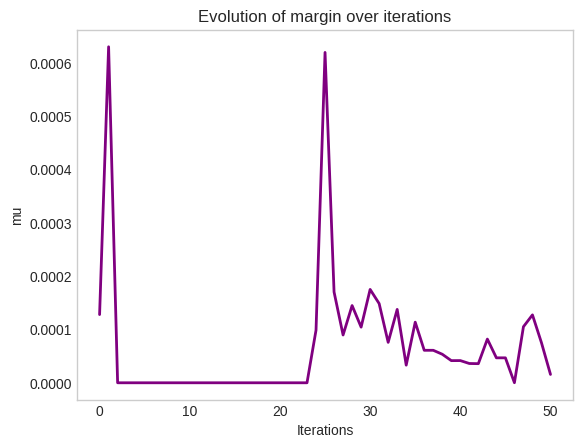

22:54:01 | INFO | machinemoo | Fit runtime: 529.76 seconds


In [9]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

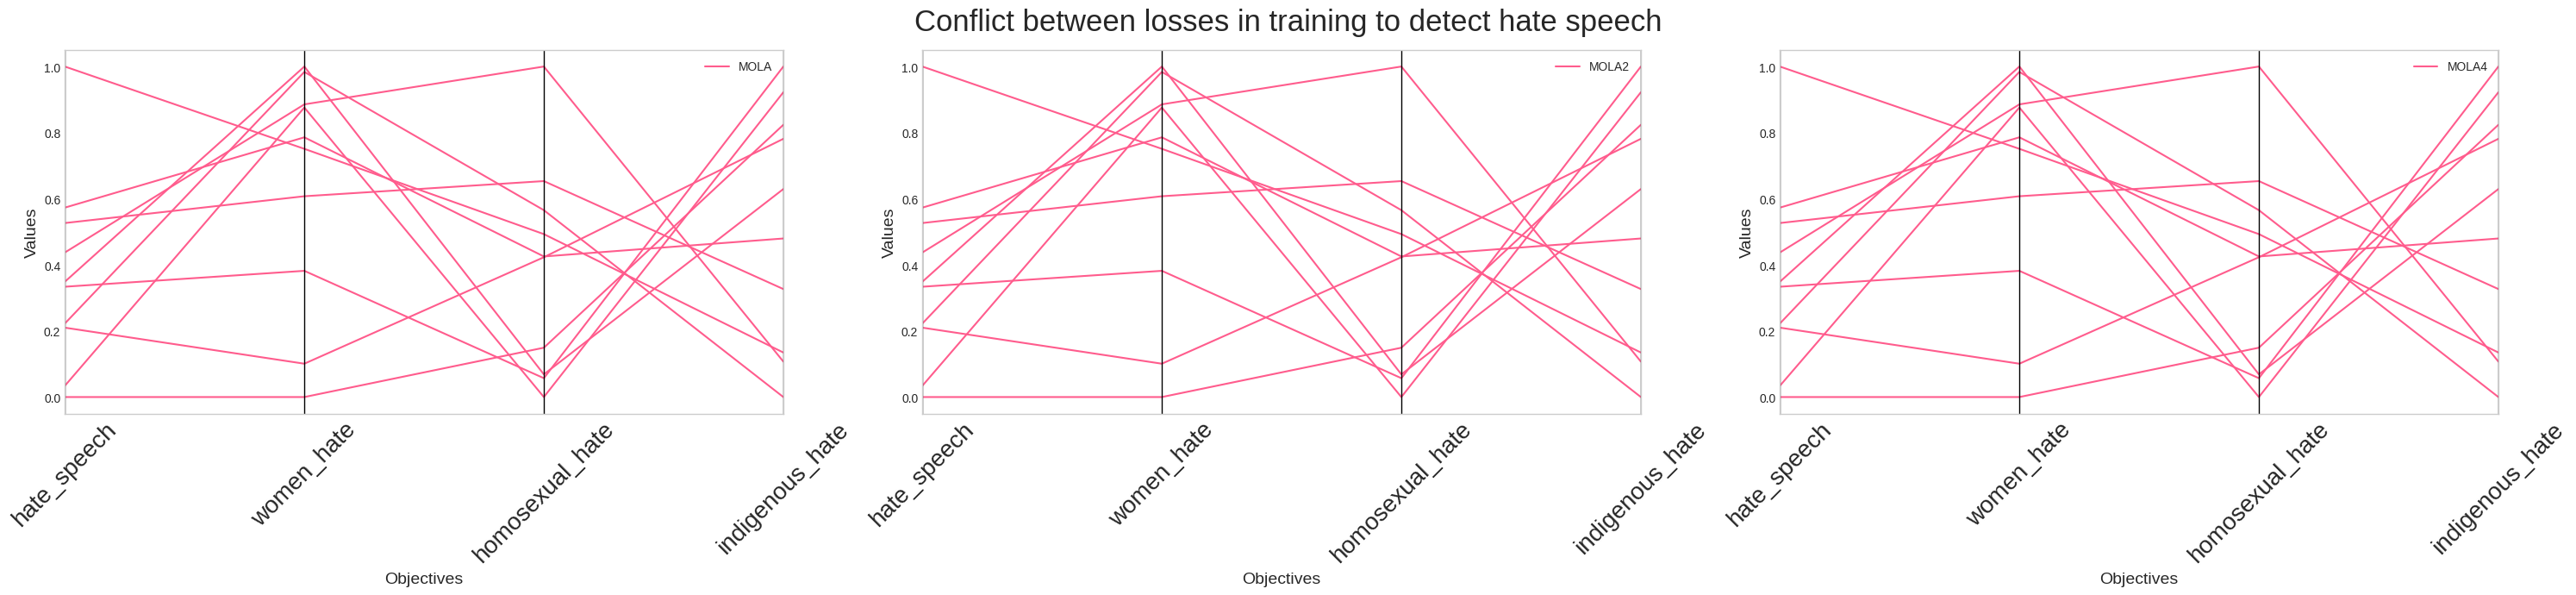

In [ ]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_mola.pdf'
            )

18:50:52 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
18:50:52 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 103.67it/s]


Epoch 1 - Average loss: 0.1780


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 105.31it/s]


Epoch 2 - Average loss: 0.1748


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 105.29it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 103.73it/s]


Epoch 2 - Average loss: 0.1527


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 103.96it/s]


Epoch 3 - Average loss: 0.1532
new solution added [0.58920931 0.35232948 0.26823201 0.02295018]
load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


19:45:21 | DEBUG | machinemoo | Calculated weights: [9.99995012e-01 0.00000000e+00 1.17162642e-06 3.81601499e-06]
19:45:21 | DEBUG | machinemoo | Importance: -3.9339200785804e-09
19:45:21 | DEBUG | machinemoo | Global lower bound (y*): [0.58879927 0.35150115 0.26678063 0.02111814]
19:45:21 | DEBUG | machinemoo | Iteration 301
19:45:21 | DEBUG | machinemoo | Solutions list: [array([0.58920931, 0.35232948, 0.26823201, 0.02295018]), array([0.59035398, 0.35377617, 0.26939839, 0.02111814]), array([0.59019978, 0.3538857 , 0.27024157, 0.02112898]), array([0.59025141, 0.35477044, 0.26953869, 0.0218469 ]), array([0.58941685, 0.35218854, 0.26801944, 0.02295564]), array([0.58885149, 0.35221711, 0.26844436, 0.02297012]), array([0.58920098, 0.35234643, 0.26816127, 0.02296335]), array([0.5895533 , 0.35269692, 0.26816118, 0.02294124]), array([0.58941791, 0.3522149 , 0.26866168, 0.02293907]), array([0.58899601, 0.35200537, 0.26837799, 0.02296734]), array([0.58936285, 0.35239441, 0.26897852, 0.02289502

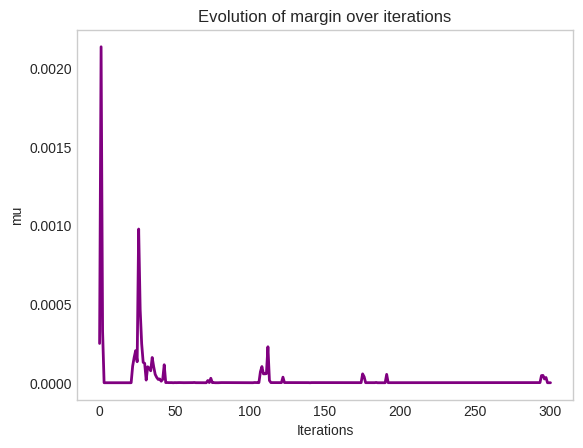

19:45:21 | INFO | machinemoo | Fit runtime: 3268.75 seconds


In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

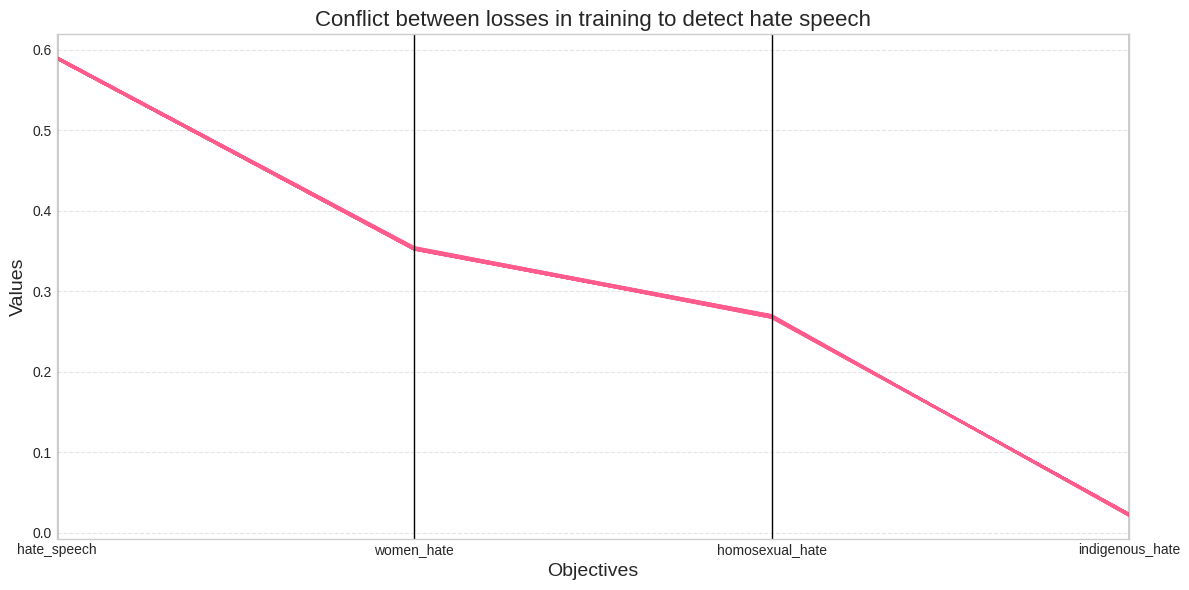

In [ ]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola_grad': objs},
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_mola_grad.pdf'
            )

### Random Weight

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

19:45:21 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeGap', 'targetGap', 'nodeTimeLimit'}
19:45:21 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
19:45:21 | DEBUG | machinemoo.moo.random_weights | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 100.08it/s]


Epoch 1 - Average loss: 0.1732


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 106.02it/s]


Epoch 2 - Average loss: 0.1706


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 104.64it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 110.40it/s]


Epoch 2 - Average loss: 0.0632


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 113.96it/s]


Epoch 3 - Average loss: 0.0633


20:27:23 | DEBUG | machinemoo.moo.random_weights | 300th solution


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [ ]:
from machinemoo.analysis.visualization import plot_multiple_hypervolumes

20:27:23 | WARNING | machinemoo | [Methods have different numbers of solutions: {76, 69, 300}


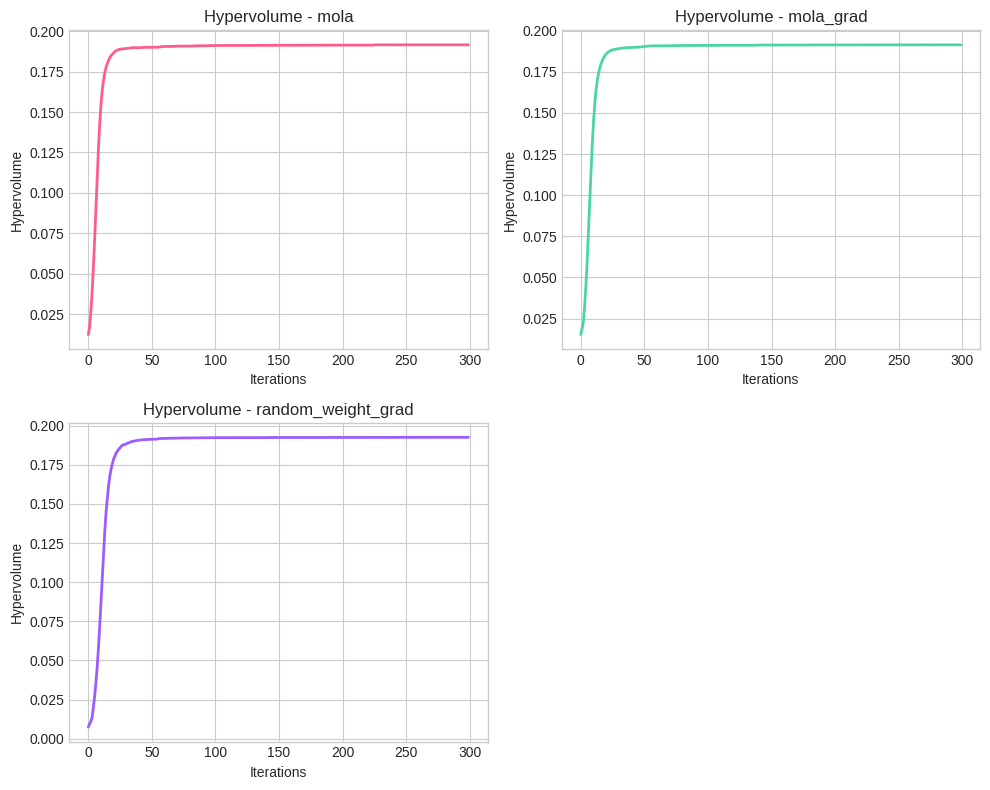

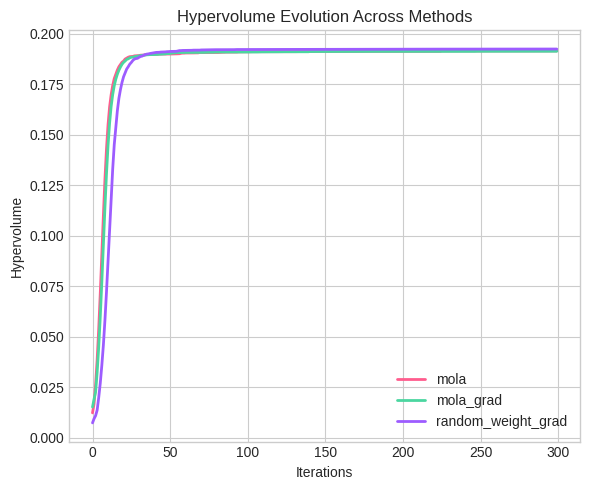

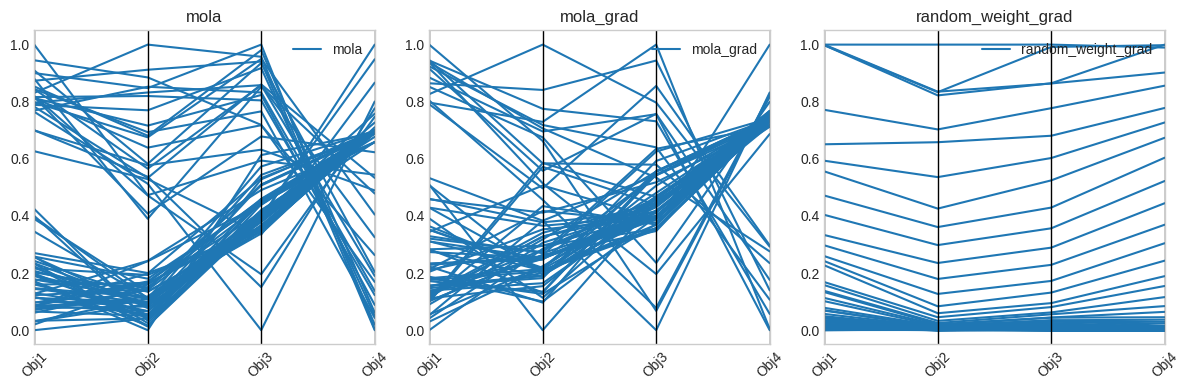

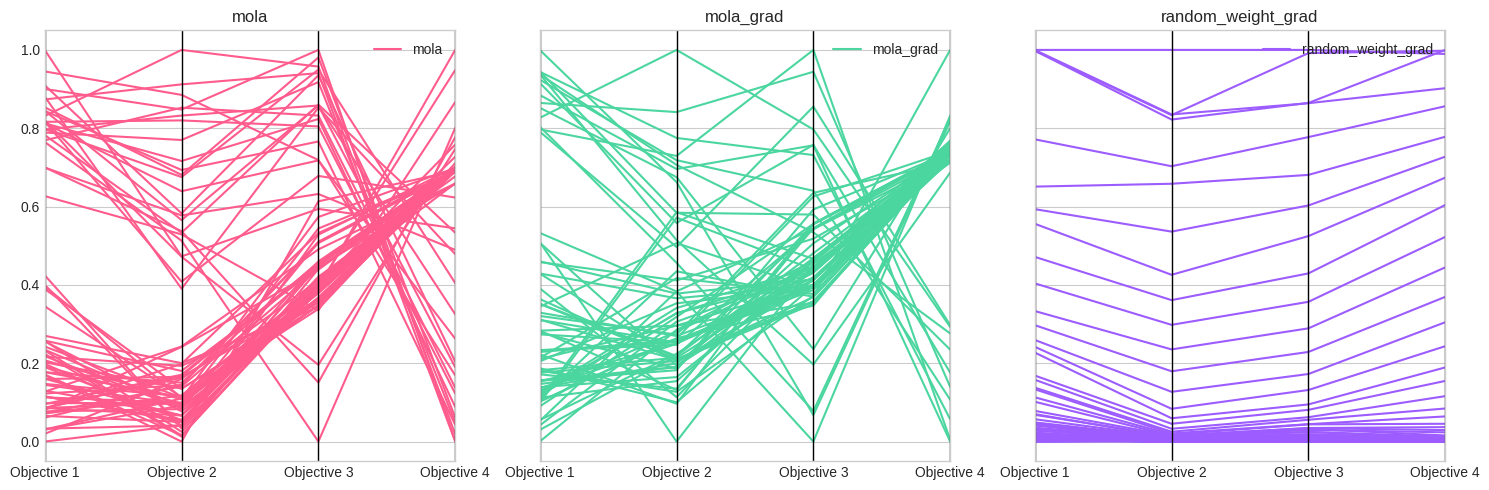

[Analyzer] Visualization complete.


: 

In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
plot_pareto(methods=pareto_dict,
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)